In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df=pd.read_csv(r"C:\Users\USER\Desktop\5th sem\project1_daibatise\data\processed\project1_diabetes_clean.csv",parse_dates=["last_checkup_date"])

In [50]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unkown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unkown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [51]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

In [52]:
df.shape

(950, 14)

create an age -band feature

In [53]:
df['age_band'] = pd.cut(
    df['age'],bins=[0,35, 55,120] ,labels=("youth","middle_aged","senior")
)

In [54]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unkown,NO,2023-04-20,0,senior
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle_aged
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKOWN,2023-07-08,0,middle_aged
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unkown,YES,2024-04-14,1,senior
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior


create bmi category feautre

In [55]:
df["bmi_category"] = pd.cut(
    df['bmi'], bins=[0,18.5,25,30,100],
labels=["underweight","normal","overweight","obese"])

In [56]:
df.head(20)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unkown,NO,2023-04-20,0,senior,normal
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle_aged,obese
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKOWN,2023-07-08,0,middle_aged,overweight
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unkown,YES,2024-04-14,1,senior,overweight
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,middle_aged,normal
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,senior,overweight
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,senior,obese
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKOWN,2023-10-15,1,youth,normal
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,senior,obese


In [57]:
df['bmi_category'].value_counts()

bmi_category
obese          553
overweight     235
normal         124
underweight     38
Name: count, dtype: int64

check the glucose band distribution

In [58]:
df["glucose_band"] = pd.cut(
    df['glucose'], bins=[0,100,126,300,],
labels=["normal","prediabetic","diabetic"])

In [59]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unkown,NO,2023-04-20,0,senior,normal,prediabetic
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle_aged,obese,diabetic
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKOWN,2023-07-08,0,middle_aged,overweight,diabetic
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unkown,YES,2024-04-14,1,senior,overweight,prediabetic
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal,prediabetic


In [60]:
df['glucose_band'].value_counts()

glucose_band
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

In [61]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']


In [62]:
df['insulin_glucose_ratio'].head(10)

0    1.000000
1    0.274510
2    1.119718
3    1.024793
4    0.943925
5    0.855172
6    1.789474
7    0.826667
8    1.751938
9    1.248447
Name: insulin_glucose_ratio, dtype: float64

check the ratio for impossible value

In [63]:
df['insulin_glucose_ratio'].describe()

count    950.000000
mean       1.213108
std        1.179183
min        0.054348
25%        0.726708
50%        1.052139
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

In [64]:
import numpy as np

In [65]:
np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

create a pregnancies-pe-year-of-age feature

In [66]:
df['pregnancy_rate']=df['pregnancies']/df['age']

In [67]:
np.isinf(df['pregnancy_rate']).sum()

np.int64(0)

In [68]:
df['pregnancy_rate'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancy_rate, dtype: float64

create a days since last checkup feature

In [69]:
reference_date=df['last_checkup_date'].max()
reference_date

Timestamp('2024-12-28 00:00:00')

create a categorical combination feature

In [70]:
df['since_checkup'] = (reference_date-df['last_checkup_date']).dt.days

In [71]:
df['since_checkup'].head()

0    618
1    239
2    539
3    258
4    336
Name: since_checkup, dtype: int64

check the    combination feature balance

In [72]:
df['activity_smoker'] = df['physical_activity'] +"/" + df["smoker"]

In [73]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO        207
High/NO          195
Low/NO           180
Low/YES           93
Medium/YES        90
High/YES          85
Unkown/NO         36
High/UNKOWN       22
Unkown/YES        17
Medium/UNKOWN     12
Low/UNKOWN         9
Unkown/UNKOWN      4
Name: count, dtype: int64

inventory every new columns

In [74]:
# activity smoker = physical activity + smoker
# since_checkup = reference- last_checkup_date
# pregence_rate = pregnency/age
# insulin_glucose = insulin/glucose
# glucose_band = glucose
# bmi_category=bmi
# age_band=age 

In [75]:
df.shape

(950, 21)

# exploratory analysis

re-run the group comparison on orginal feature

In [76]:
numeric_cols=['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi']
df.groupby('outcome')[numeric_cols].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi
outcome,,,,,,,
0,47.874446,1.828656,112.220027,72.350074,26.370753,131.490399,30.941359
1,54.798535,1.915751,131.868081,71.930403,26.047619,132.388278,32.516850


In [77]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,pregnancy_rate,since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,prediabetic,1.000000,0.000000,618,Unkown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle_aged,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKOWN,2023-07-08,0,middle_aged,overweight,diabetic,1.119718,0.000000,539,Low/UNKOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,prediabetic,1.024793,0.102941,258,Unkown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,prediabetic,0.943925,0.000000,336,Low/NO


In [78]:
enginierd_numeric=['insulin_glucose_ratio','pregnancy_rate','since_checkup']
df.groupby('outcome')[enginierd_numeric].mean()

,insulin_glucose_ratio,pregnancy_rate,since_checkup
outcome,,,
0,1.271066,0.044392,350.304284
1,1.069380,0.038809,366.534799


rank everything togther

In [79]:
group_means=df.groupby('outcome')[numeric_cols + enginierd_numeric].mean().T
group_means['gap'] = (group_means[1] - group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.220027,131.868081,19.648054
since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271066,1.069380,0.201686
pregnancies,1.828656,1.915751,0.087095
pregnancy_rate,0.044392,0.038809,0.005583


In [80]:
#glucose
#days_since_checkup
#age

cross_tabulate the age band against outcome

In [81]:
pd.crosstab(df['age_band'], df['outcome'], normalize="index")

outcome,0,1
age_band,,
youth,0.789683,0.210317
middle_aged,0.766871,0.233129
senior,0.612903,0.387097


In [82]:
pd.crosstab(df['bmi_category'], df['outcome'], normalize="index")

outcome,0,1
bmi_category,,
underweight,0.763158,0.236842
normal,0.750000,0.250000
overweight,0.770213,0.229787
obese,0.676311,0.323689


cross tabulate the glucose band against outcome

In [83]:
pd.crosstab(df['glucose_band'], df['outcome'], normalize="index")

outcome,0,1
glucose_band,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


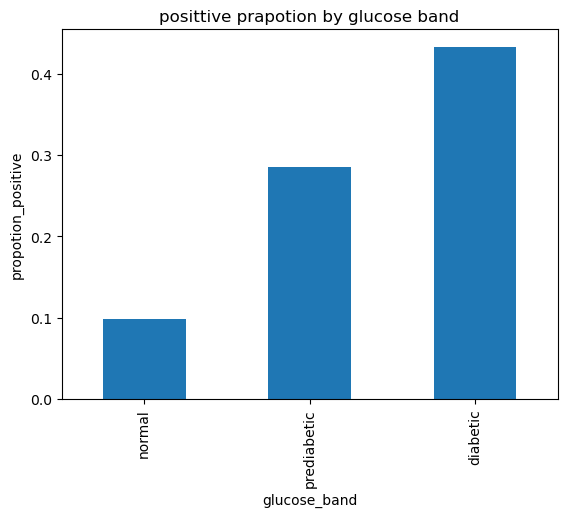

In [84]:
ax=pd.crosstab(df['glucose_band'], df['outcome'], normalize="index")[1].plot(kind="bar")
ax.set_xlabel('glucose_band')
ax.set_ylabel('propotion_positive')
ax.set_title('posittive prapotion by glucose band')
plt.show()


In [85]:
df.to_csv(r'C:\Users\USER\Desktop\5th sem\project1_daibatise\data\processed/mohammed_ajlan_p1w1_features.csv',index=False)

In [86]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,pregnancy_rate,since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,prediabetic,1.000000,0.000000,618,Unkown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle_aged,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKOWN,2023-07-08,0,middle_aged,overweight,diabetic,1.119718,0.000000,539,Low/UNKOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,prediabetic,1.024793,0.102941,258,Unkown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,prediabetic,0.943925,0.000000,336,Low/NO
